<style>
  td, th {
    border: none!important;
    font-family: Arial, sans-serif;
    padding: 8px;
  }
  th {
    font-weight: bold;
  }
</style>

| Notebook Details |  |
|----|---|
|Host | Montanuniversitaet Leoben |
|Course | Mechanics of Composite Materials |
|Authors | Vasco D.C Pires |
|Department | Chair of Designing Plastics and Composite Materials|
|Corresponding Authors | vasco.castro-pires@unileoben.ac.at |
|Last edited |  17.03.2026 |

<div>
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTWeMORYjOsTvgceJjHADfsEqLMHCPqPjUDnw&s" width="150"/>
</div>

# Python notebook - Practical Class 6

<div class="alert alert-block alert-success">
This python notebook serves as support for the practical class about Failure Criteria.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:


# Define material properties
material = {
    "XT": 1400.,
    "XC": 980.,
    "YT": 47., 
    "YC": 130., 
    "SL": 53., 
}

Xt = material['XT']
Xc = material['XC']
Yt = material['YT']
Yc = material['YC']
S12 = material['SL']

# Generate a grid of stress values
sigma1 = np.linspace(-1.8* Xc, 1.8*Xt, 500)
sigma2 = np.linspace(-15.0 *Yc, 1.8*Yt, 500)
sigma1_grid, sigma2_grid = np.meshgrid(sigma1, sigma2)

# Assume tau12 is zero for this 2D plot
tau12 = 0

# Tsai-Hill Criterion function with tension and compression checks
def tsai_hill_criterion(sigma1, sigma2, tau12, Xt, Xc, Yt, Yc, S12):
    X = np.where(sigma1 >= 0, Xt, Xc)
    Y = np.where(sigma2 >= 0, Yt, Yc)
    return ((sigma1 / X)**2 - (sigma1 * sigma2) / (X**2) + (sigma2 / Y)**2 + (tau12 / S12)**2)

# Be careful here. In class we had Yc and Xc as negative values, however to follow the 
# expression from the slides, you need to use the absolute values of Yc and Xc
def tsai_wu_criterion(sigma1, sigma2, tau12, Xt, Xc, Yt, Yc, S12):
    F12 = -0.5/np.sqrt(Xt*Xc*Yt*Yc)
    f = sigma1**2/(Xt*Xc) + sigma2**2/(Yt*Yc) + tau12**2/S12**2 + (1/Xt-1/Xc)*sigma1 + (1/Yt-1/Yc)*sigma2 + 2*F12*sigma1*sigma2
    return f



# Calculate the Tsai-Hill criterion values
tsai_hill_sigma = tsai_hill_criterion(sigma1_grid, sigma2_grid, tau12, Xt, Xc, Yt, Yc, S12)
tsai_wu_sigma = tsai_wu_criterion(sigma1_grid, sigma2_grid, tau12, Xt, Xc, Yt, Yc, S12)


C:\Users\p2321038\AppData\Local\Temp\ipykernel_98436\1542231769.py:13: UserWarning: The following kwargs were not used by contour: 'label'
  contour = plt.contour(sigma1, sigma2, tsai_hill_sigma, levels = [1.0], colors='b', label='Tsai-Hill')
C:\Users\p2321038\AppData\Local\Temp\ipykernel_98436\1542231769.py:14: UserWarning: The following kwargs were not used by contour: 'label'
  contour_tsai_wu = plt.contour(sigma1, sigma2, tsai_wu_sigma, levels = [1.0], colors='g', label='Tsai-Wu')


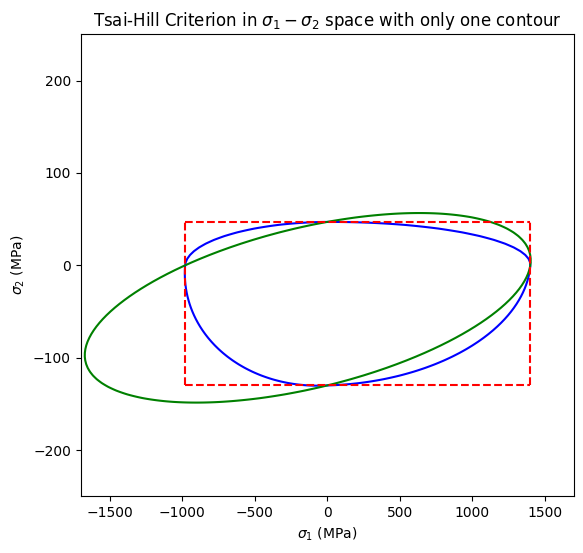

In [12]:
# Calculate the Tsai-Hill criterion values
tsai_hill_sigma = tsai_hill_criterion(sigma1_grid, sigma2_grid, tau12, Xt, Xc, Yt, Yc, S12)



# Plot Tsai-Hill Criterion
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)


## Here notice that we are plotting only one contour for the level where our Fe=1.
contour = plt.contour(sigma1, sigma2, tsai_hill_sigma, levels = [1.0], colors='b', label='Tsai-Hill')
contour_tsai_wu = plt.contour(sigma1, sigma2, tsai_wu_sigma, levels = [1.0], colors='g', label='Tsai-Wu')

plt.plot([Xt, Xt], [-Yc, Yt], 'r--')
plt.plot([-Xc, -Xc], [-Yc, Yt], 'r--')
plt.plot([-Xc, Xt], [-Yc, -Yc], 'r--')
plt.plot([-Xc, Xt], [Yt, Yt], 'r--')

# This is a label, that show us the contour levels
plt.title('Tsai-Hill Criterion in $\sigma_1 - \sigma_2$ space with only one contour')
plt.xlabel('$\sigma_1$ (MPa)')
plt.ylabel('$\sigma_2$ (MPa)')
plt.xlim([-1700, 1700])
plt.ylim([-250, 250])

plt.show()


